In [1]:
# SECTION 1 — IMPORTS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import networkx as nx

from pyvis.network import Network

In [2]:
# SECTION 2 — LOAD DATASETS

accounts_df = pd.read_csv("../data/accounts.csv")
transactions_df = pd.read_csv("../data/transactions.csv")
alerts_df = pd.read_csv("../data/alerts.csv")

In [5]:
# SECTION 3 — INITIAL INSPECTION
accounts_df.head()

,ACCOUNT_ID,CUSTOMER_ID,INIT_BALANCE,COUNTRY,ACCOUNT_TYPE,IS_FRAUD,TX_BEHAVIOR_ID
0,0,C_0,184.44,US,I,False,1
1,1,C_1,175.80,US,I,False,1
2,2,C_2,142.06,US,I,False,1
3,3,C_3,125.89,US,I,False,1
4,4,C_4,151.13,US,I,False,1


In [3]:
transactions_df.head()


,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID
0,1,6456,9069,TRANSFER,465.05,0,False,-1
1,2,7516,9543,TRANSFER,564.64,0,False,-1
2,3,2445,9356,TRANSFER,598.94,0,False,-1
3,4,2576,4617,TRANSFER,466.07,0,False,-1
4,5,3524,1773,TRANSFER,405.63,0,False,-1


In [4]:
# 1. DATASET SHAPES
print(accounts_df.shape)

print(transactions_df.shape)

print(alerts_df.shape)

# We need:

# graph size,
# scale understanding.

(10000, 7)
(1323234, 8)
(1719, 9)


In [10]:
# 3. ALERT TYPES
alerts_df["ALERT_TYPE"].value_counts()

# This is VERY important for:

# AML pattern taxonomy.

ALERT_TYPE
cycle     936
fan_in    783
Name: count, dtype: int64

In [11]:
# 2. FRAUD DISTRIBUTION

# VERY important.

accounts_df["IS_FRAUD"].value_counts()

# and:

transactions_df["IS_FRAUD"].value_counts()

# This tells us:

# class imbalance.

# Critical for future GNN training.

IS_FRAUD
False    1321515
True        1719
Name: count, dtype: int64

<Axes: xlabel='TX_AMOUNT', ylabel='Count'>

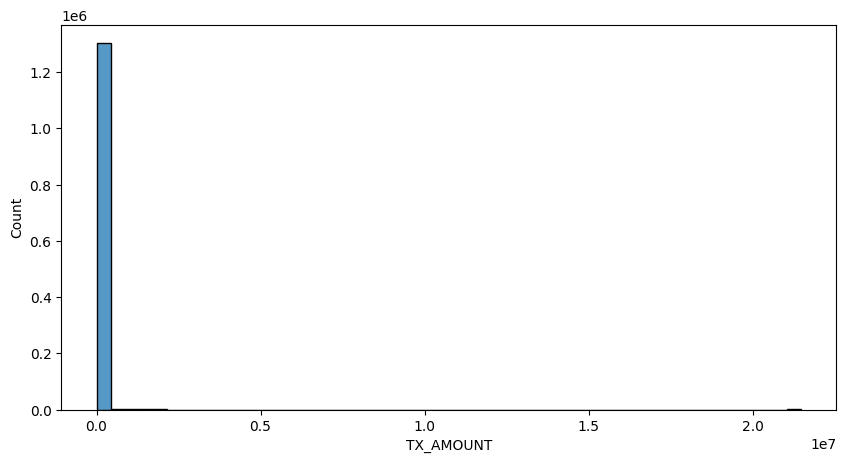

In [12]:
# 4. TRANSACTION AMOUNT DISTRIBUTION
plt.figure(figsize=(10,5))

sns.histplot(
    transactions_df["TX_AMOUNT"],
    bins=50
)

In [8]:
# 5. BUILD FIRST GRAPH

# THIS is the BIG step.

# Run:

G = nx.from_pandas_edgelist(
    transactions_df,
    source="SENDER_ACCOUNT_ID",
    target="RECEIVER_ACCOUNT_ID",
    edge_attr=True,
    create_using=nx.DiGraph()
)

In [9]:
# 6. GRAPH SIZE
print("Nodes:", G.number_of_nodes())

print("Edges:", G.number_of_edges())

Nodes: 9999
Edges: 68947


In [10]:
# 7. BASIC CENTRALITY
degree_centrality = nx.degree_centrality(G)
print(degree_centrality)

{6456: 0.0003000600120024005, 9069: 0.003900780156031206, 7516: 0.0008001600320064013, 9543: 0.002000400080016003, 2445: 0.0007001400280056011, 9356: 0.004100820164032806, 2576: 0.000600120024004801, 4617: 0.0013002600520104022, 3524: 0.000600120024004801, 1773: 0.0010002000400080016, 7123: 0.002000400080016003, 3327: 0.001200240048009602, 9711: 0.00640128025605121, 4660: 0.0014002800560112022, 7018: 0.001900380076015203, 8957: 0.0017003400680136028, 9637: 0.005201040208041609, 5746: 0.0014002800560112022, 9915: 0.003900780156031206, 8293: 0.0022004400880176033, 9816: 0.0029005801160232048, 2060: 0.0011002200440088017, 6491: 0.0008001600320064013, 8506: 0.0008001600320064013, 5360: 0.0016003200640128026, 382: 0.0007001400280056011, 8211: 0.0026005201040208044, 6613: 0.0015003000600120023, 9975: 0.008801760352070413, 2775: 0.0014002800560112022, 9998: 0.01820364072814563, 9968: 0.007301460292058411, 9979: 0.009801960392078415, 9527: 0.0015003000600120023, 5515: 0.000600120024004801, 361

In [11]:
# 8. MOST CONNECTED ACCOUNTS
sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

# This identifies:

# transaction hubs.

# Potentially:

# mule accounts,
# laundering aggregators,
# suspicious central nodes.

[(9999, 0.021704340868173636),
 (9998, 0.01820364072814563),
 (9993, 0.017303460692138426),
 (9982, 0.015303060612122424),
 (9997, 0.015303060612122424),
 (9996, 0.015003000600120024),
 (9994, 0.014902980596119223),
 (9992, 0.01270254050810162),
 (9995, 0.01260252050410082),
 (9990, 0.01240248049609922)]

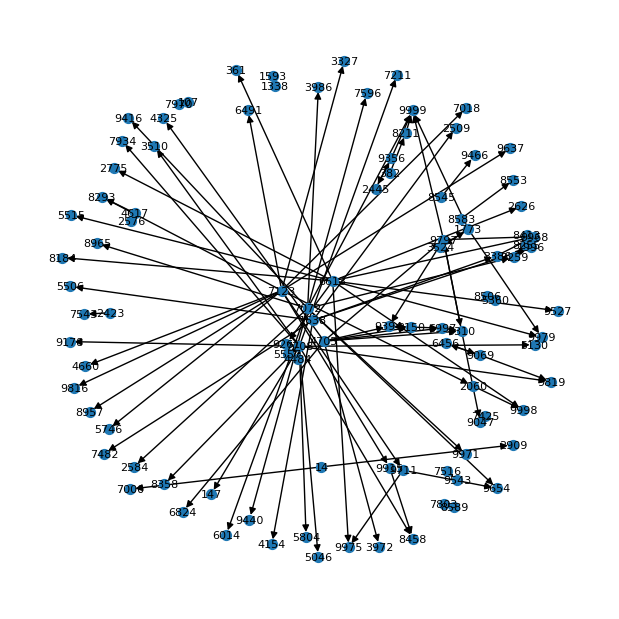

In [12]:
## 2d notes ve edges

# FIRST SIMPLE 2D GRAPH

# Run this:

plt.figure(figsize=(6,6))

sample_nodes = list(G.nodes())[:100]

subgraph = G.subgraph(sample_nodes)

nx.draw(
    subgraph,
    with_labels=True,
    node_size=50,
    font_size=8
)

plt.show()

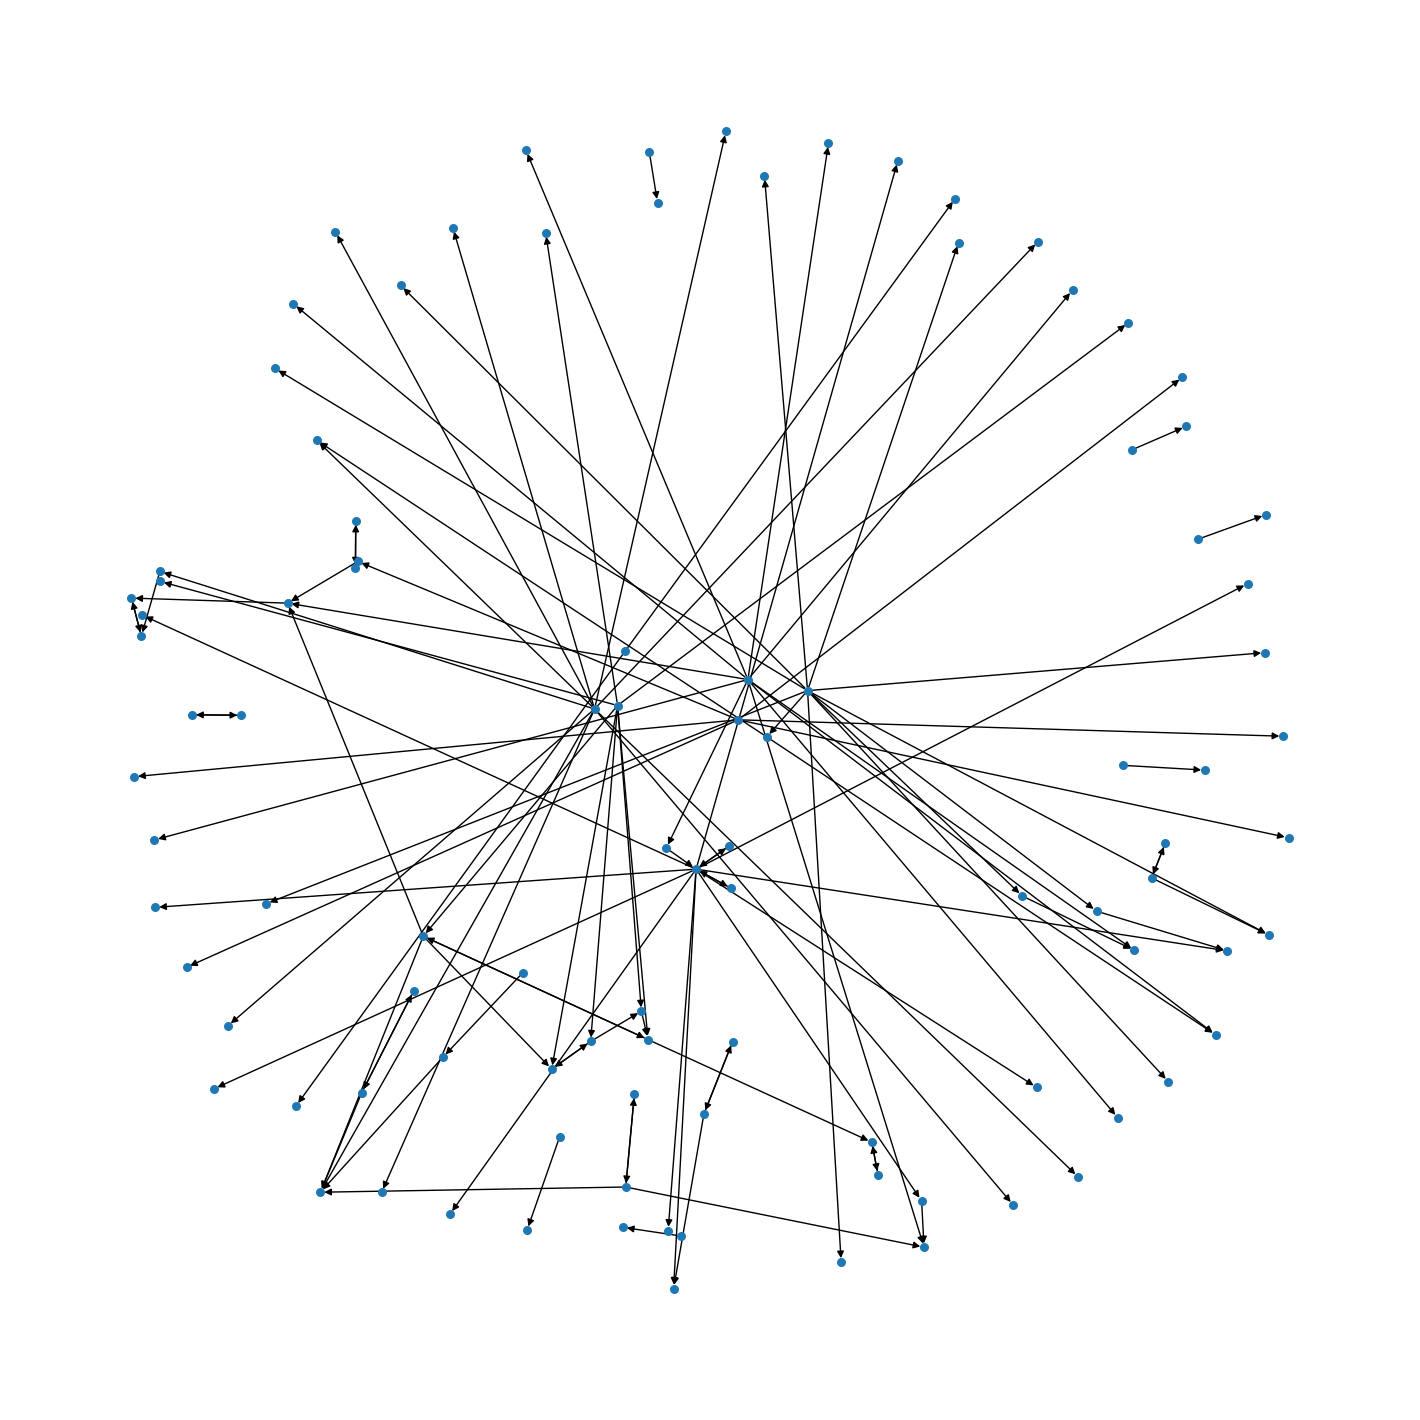

In [24]:
# BETTER VISUALIZATION (RECOMMENDED)

# Add layout positioning:

plt.figure(figsize=(14,14))

pos = nx.spring_layout(
    subgraph,
    k=0.15
)

nx.draw(
    subgraph,
    pos,
    with_labels=False,
    node_size=30,
    arrows=True
)

plt.show()

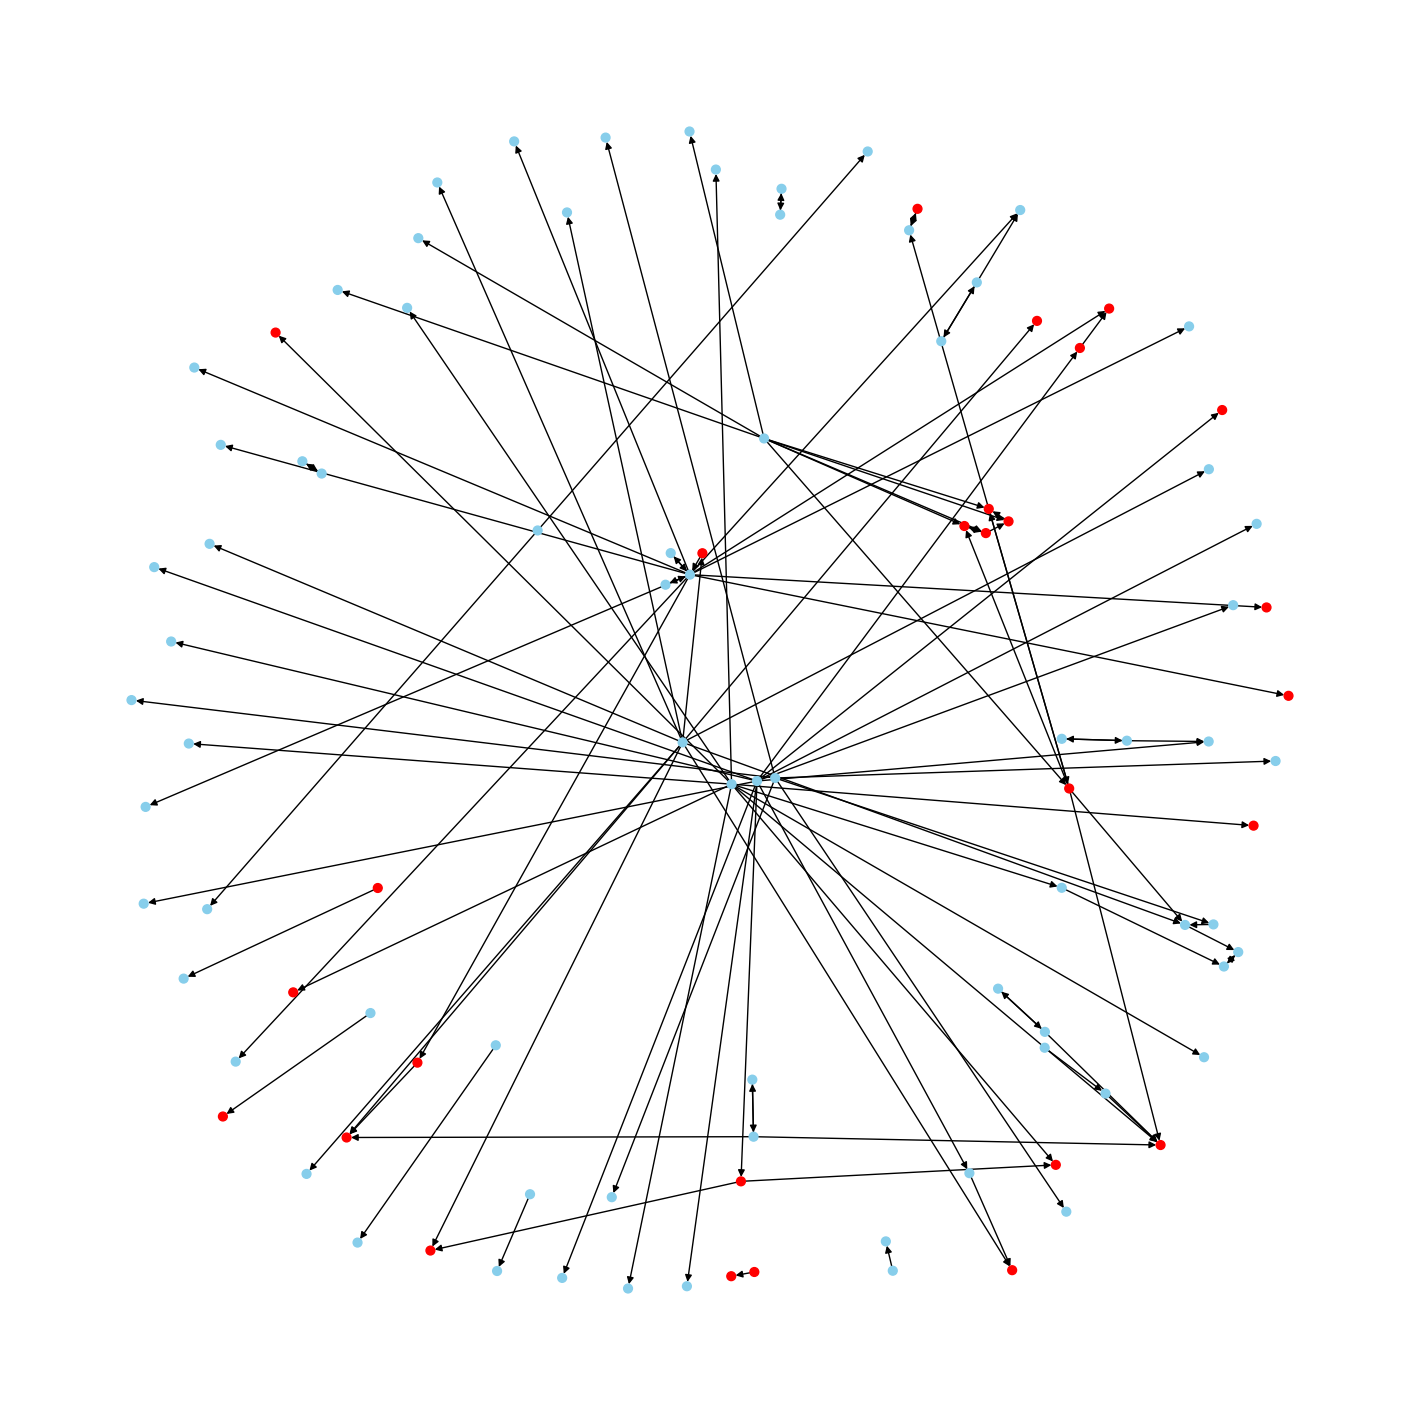

In [26]:
fraud_accounts = set(
    accounts_df[
        accounts_df["IS_FRAUD"] == True
    ]["ACCOUNT_ID"]
)
node_colors = []

for node in subgraph.nodes():

    if node in fraud_accounts:
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

plt.figure(figsize=(14,14))

pos = nx.spring_layout(subgraph)

nx.draw(
    subgraph,
    pos,
    node_color=node_colors,
    node_size=40,
    with_labels=False,
    arrows=True
)

plt.show()

In [18]:
alerts_df.head()

,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP
0,193,fan_in,True,82,6976,9739,TRANSFER,4.85,0
1,377,cycle,True,949,5776,2570,TRANSFER,10.27,0
2,189,fan_in,True,6280,9999,9530,TRANSFER,2.74,1
3,377,cycle,True,7999,1089,7352,TRANSFER,10.27,1
4,130,fan_in,True,12975,7025,9708,TRANSFER,3.53,2


In [19]:
accounts_df.info()

transactions_df.info()



transactions_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      10000 non-null  int64  
 1   CUSTOMER_ID     10000 non-null  str    
 2   INIT_BALANCE    10000 non-null  float64
 3   COUNTRY         10000 non-null  str    
 4   ACCOUNT_TYPE    10000 non-null  str    
 5   IS_FRAUD        10000 non-null  bool   
 6   TX_BEHAVIOR_ID  10000 non-null  int64  
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 478.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 1323234 entries, 0 to 1323233
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TX_ID                1323234 non-null  int64  
 1   SENDER_ACCOUNT_ID    1323234 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  1323234 non-null  int64  
 3   TX_TYPE              1323234 non-null  str    
 4   TX_AMOUNT   

,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_AMOUNT,TIMESTAMP,ALERT_ID
count,1.323234e+06,1.323234e+06,1.323234e+06,1.323234e+06,1.323234e+06,1.323234e+06
mean,6.616175e+05,6.026110e+03,6.805872e+03,1.159882e+05,9.997826e+01,-7.284003e-01
std,3.819849e+05,2.919641e+03,2.845101e+03,1.320091e+06,5.752707e+01,8.594027e+00
min,1.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00
25%,3.308092e+05,3.610000e+03,4.665000e+03,2.393000e+01,5.000000e+01,-1.000000e+00
50%,6.616175e+05,6.534000e+03,7.585000e+03,1.567100e+02,1.000000e+02,-1.000000e+00
75%,9.924258e+05,8.691000e+03,9.355000e+03,4.400000e+02,1.500000e+02,-1.000000e+00
max,1.323234e+06,9.999000e+03,9.999000e+03,2.147484e+07,1.990000e+02,3.990000e+02


In [31]:
alerts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1719 entries, 0 to 1718
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ALERT_ID             1719 non-null   int64  
 1   ALERT_TYPE           1719 non-null   str    
 2   IS_FRAUD             1719 non-null   bool   
 3   TX_ID                1719 non-null   int64  
 4   SENDER_ACCOUNT_ID    1719 non-null   int64  
 5   RECEIVER_ACCOUNT_ID  1719 non-null   int64  
 6   TX_TYPE              1719 non-null   str    
 7   TX_AMOUNT            1719 non-null   float64
 8   TIMESTAMP            1719 non-null   int64  
dtypes: bool(1), float64(1), int64(5), str(2)
memory usage: 109.2 KB


In [29]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1323234 entries, 0 to 1323233
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TX_ID                1323234 non-null  int64  
 1   SENDER_ACCOUNT_ID    1323234 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  1323234 non-null  int64  
 3   TX_TYPE              1323234 non-null  str    
 4   TX_AMOUNT            1323234 non-null  float64
 5   TIMESTAMP            1323234 non-null  int64  
 6   IS_FRAUD             1323234 non-null  bool   
 7   ALERT_ID             1323234 non-null  int64  
dtypes: bool(1), float64(1), int64(5), str(1)
memory usage: 71.9 MB


<Axes: xlabel='TX_AMOUNT', ylabel='Count'>

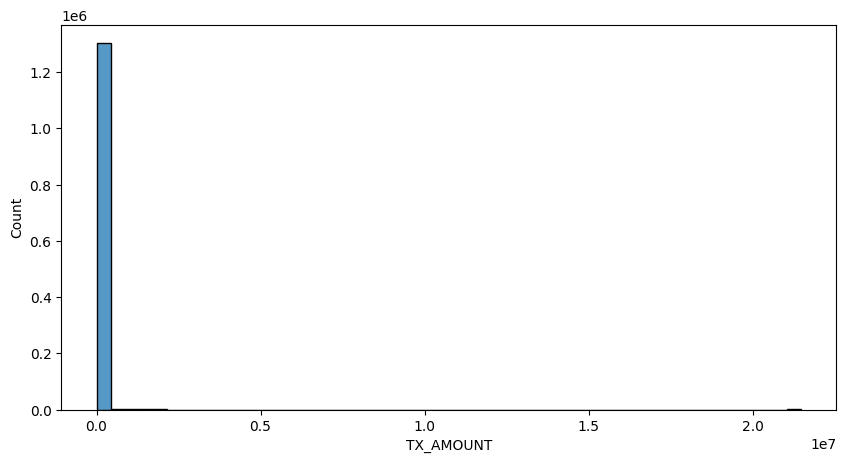

In [30]:
# Transaction Amount Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    transactions_df["TX_AMOUNT"],
    bins=50
)

In [32]:
# Alert Frequency
alerts_df["ALERT_TYPE"].value_counts()

ALERT_TYPE
cycle     936
fan_in    783
Name: count, dtype: int64

In [6]:
# Most Active Accounts
transactions_df["SENDER_ACCOUNT_ID"].value_counts().head(20)

SENDER_ACCOUNT_ID
9799    963
9797    962
9785    922
9793    921
9790    921
9792    921
9784    921
9794    920
9798    920
9796    920
9795    920
9783    901
9781    901
9787    900
9791    900
9776    900
9789    900
9788    900
9773    881
9786    880
Name: count, dtype: int64

In [ ]:
# INITIAL NETWORKX GRAPH

In [35]:
# STEP 11 — BASIC GRAPH ANALYSIS

# Now investigate:

G.number_of_nodes()

# G.number_of_edges()
# CENTRALITY
degree_centrality = nx.degree_centrality(G)
# SUSPICIOUS HUBS
sorted(
    degree_centrality.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

[(9999, 0.021704340868173636),
 (9998, 0.01820364072814563),
 (9993, 0.017303460692138426),
 (9982, 0.015303060612122424),
 (9997, 0.015303060612122424),
 (9996, 0.015003000600120024),
 (9994, 0.014902980596119223),
 (9992, 0.01270254050810162),
 (9995, 0.01260252050410082),
 (9990, 0.01240248049609922)]

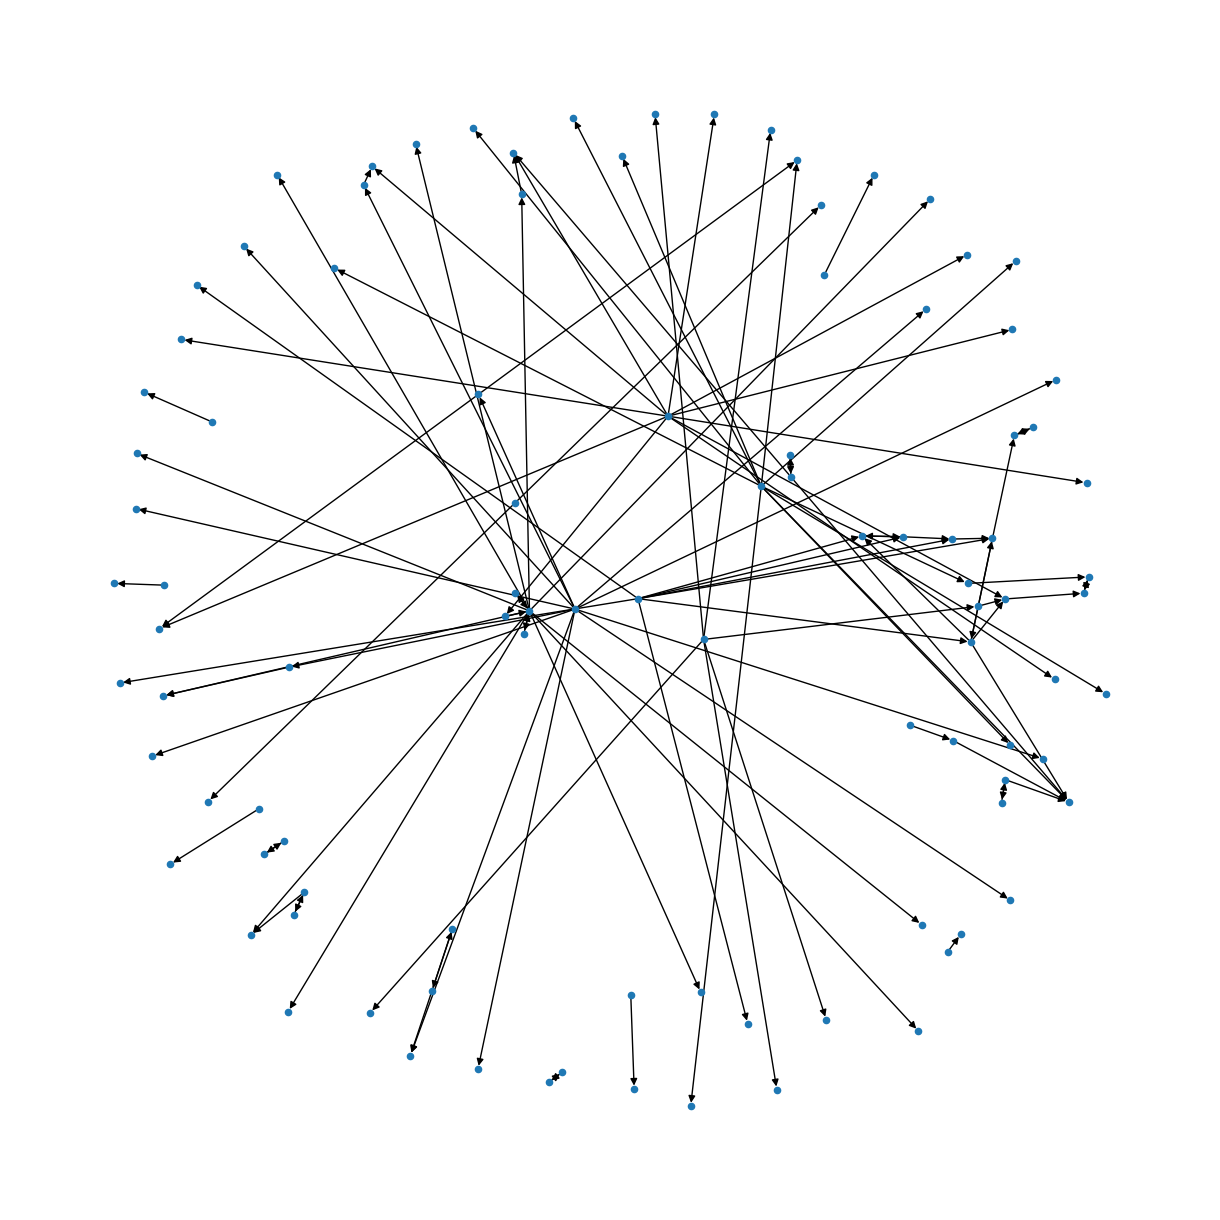

In [36]:
# STEP 12 — GRAPH VISUALIZATION

# VERY important for:

# explainability.
# Small Subgraph
subgraph_nodes = list(G.nodes())[:100]

subgraph = G.subgraph(subgraph_nodes)
# Draw
plt.figure(figsize=(12,12))

nx.draw(
    subgraph,
    node_size=20,
    with_labels=False
)

In [ ]:
# STEP 13 — AML PATTERN DISCOVERY

# THIS is where the real intelligence starts.

# Look for:

# hubs,
# fan-in patterns,
# fan-out patterns,
# circular transfers,
# rapid chains,
# suspicious clusters.

# These become:

# future AML agent reasoning patterns.

In [ ]:
# STEP 14 — DEFINE GRAPH LABELS

# We need to identify:

# supervised learning targets.

# Examples:

# laundering accounts,
# suspicious transactions,
# alerted accounts.

# This becomes:

# GNN training labels.
# VERY IMPORTANT DESIGN PRINCIPLE

# The future LLM should NOT decide fraud independently.

# Instead:

# Graph Intelligence
#         ↓
# Structured Evidence
#         ↓
# LLM Explanation



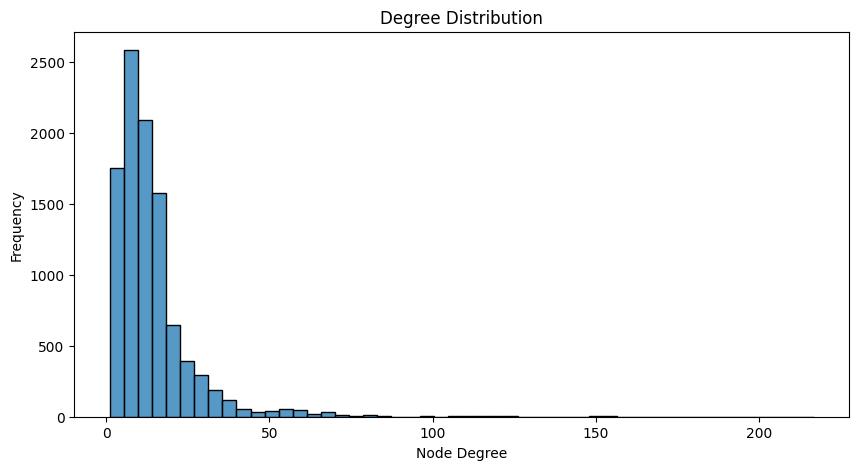

In [14]:
# 1. DEGREE DISTRIBUTION

# This shows:

# connectivity behavior.
degrees = [G.degree(n) for n in G.nodes()]

plt.figure(figsize=(10,5))

sns.histplot(degrees, bins=50)

plt.title("Degree Distribution")

plt.xlabel("Node Degree")

plt.ylabel("Frequency")

plt.show()

# WHAT THIS SHOWS

# You will likely discover:

# most accounts have few connections,
# few accounts have MANY connections.

# Those extreme nodes are:

# suspicious hubs.

In [15]:
# 2. TOP 20 MOST CONNECTED ACCOUNTS
top_nodes = sorted(
    G.degree,
    key=lambda x: x[1],
    reverse=True
)[:20]

print(top_nodes)
# This identifies:

# major graph hubs.

[(9999, 217), (9998, 182), (9993, 173), (9982, 153), (9997, 153), (9996, 150), (9994, 149), (9992, 127), (9995, 126), (9990, 124), (9991, 122), (9986, 120), (9980, 120), (9989, 118), (9983, 117), (9984, 114), (9981, 113), (9971, 109), (9988, 108), (9987, 106)]


In [16]:
# 3. CHECK IF HUBS ARE FRAUD

# VERY important.

fraud_accounts = set(
    accounts_df[
        accounts_df["IS_FRAUD"] == True
    ]["ACCOUNT_ID"]
)

for node, degree in top_nodes:

    print(
        node,
        degree,
        node in fraud_accounts
    )

# WHY THIS MATTERS

# If:

# major hubs are fraudulent,

# then:

# graph topology is highly predictive.

# That is extremely important for:

# GNN performance,
# AML reasoning,
# graph explainability.

9999 217 True
9998 182 True
9993 173 True
9982 153 True
9997 153 True
9996 150 True
9994 149 True
9992 127 True
9995 126 True
9990 124 True
9991 122 True
9986 120 True
9980 120 True
9989 118 True
9983 117 True
9984 114 True
9981 113 True
9971 109 True
9988 108 True
9987 106 True


In [ ]:
# graph intelligence primitives.

# These primitives later power:

# GNN training,
# AML agents,
# investigation reasoning,
# explainable AI,
# GraphRAG systems.

# This is exactly how enterprise AML graph platforms are engineered.

In [ ]:

# Now you are entering:

# local graph intelligence analysis.

# This is where:

# GraphRAG thinking starts.

# Because now the question becomes:

# What suspicious neighborhood surrounds this account?

# instead of:

# Is this one transaction suspicious?

# That is a HUGE architectural leap.

In [ ]:
# WHAT IS A "2-HOP NEIGHBORHOOD"?

# Suppose:

# A → B → C

# If you investigate:

# B

# then:

# 1-hop neighbors:
# A
# C
# 2-hop neighbors:
# neighbors of A and C

# This gives:

# local laundering ecosystem.

In [17]:
# STEP 1 — FIND FRAUD ACCOUNTS

# Run:

fraud_accounts = accounts_df[
    accounts_df["IS_FRAUD"] == True
]["ACCOUNT_ID"].tolist()

fraud_accounts[:10]



[49, 67, 86, 91, 113, 138, 153, 177, 182, 189]

In [18]:

# Pick one suspicious account.
# Example:

target_account = fraud_accounts[0]

target_account

49

In [19]:
# STEP 2 — EXTRACT 2-HOP NEIGHBORHOOD

# Run:

neighbors_1 = set(nx.neighbors(G, target_account))

neighbors_2 = set()

for neighbor in neighbors_1:

    neighbors_2.update(
        nx.neighbors(G, neighbor)
    )

subgraph_nodes = (
    {target_account}
    | neighbors_1
    | neighbors_2
)

In [ ]:
# WHAT THIS DOES

# It builds:

# local investigation network.

# Containing:

# suspicious account,
# directly connected accounts,
# secondary connected accounts.

In [21]:
# STEP 3 — CREATE LOCAL SUBGRAPH
local_subgraph = G.subgraph(subgraph_nodes)

In [22]:
# STEP 4 — COLOR FRAUD NODES
node_colors = []

for node in local_subgraph.nodes():

    if node in fraud_accounts:
        node_colors.append("red")
    else:
        node_colors.append("skyblue")

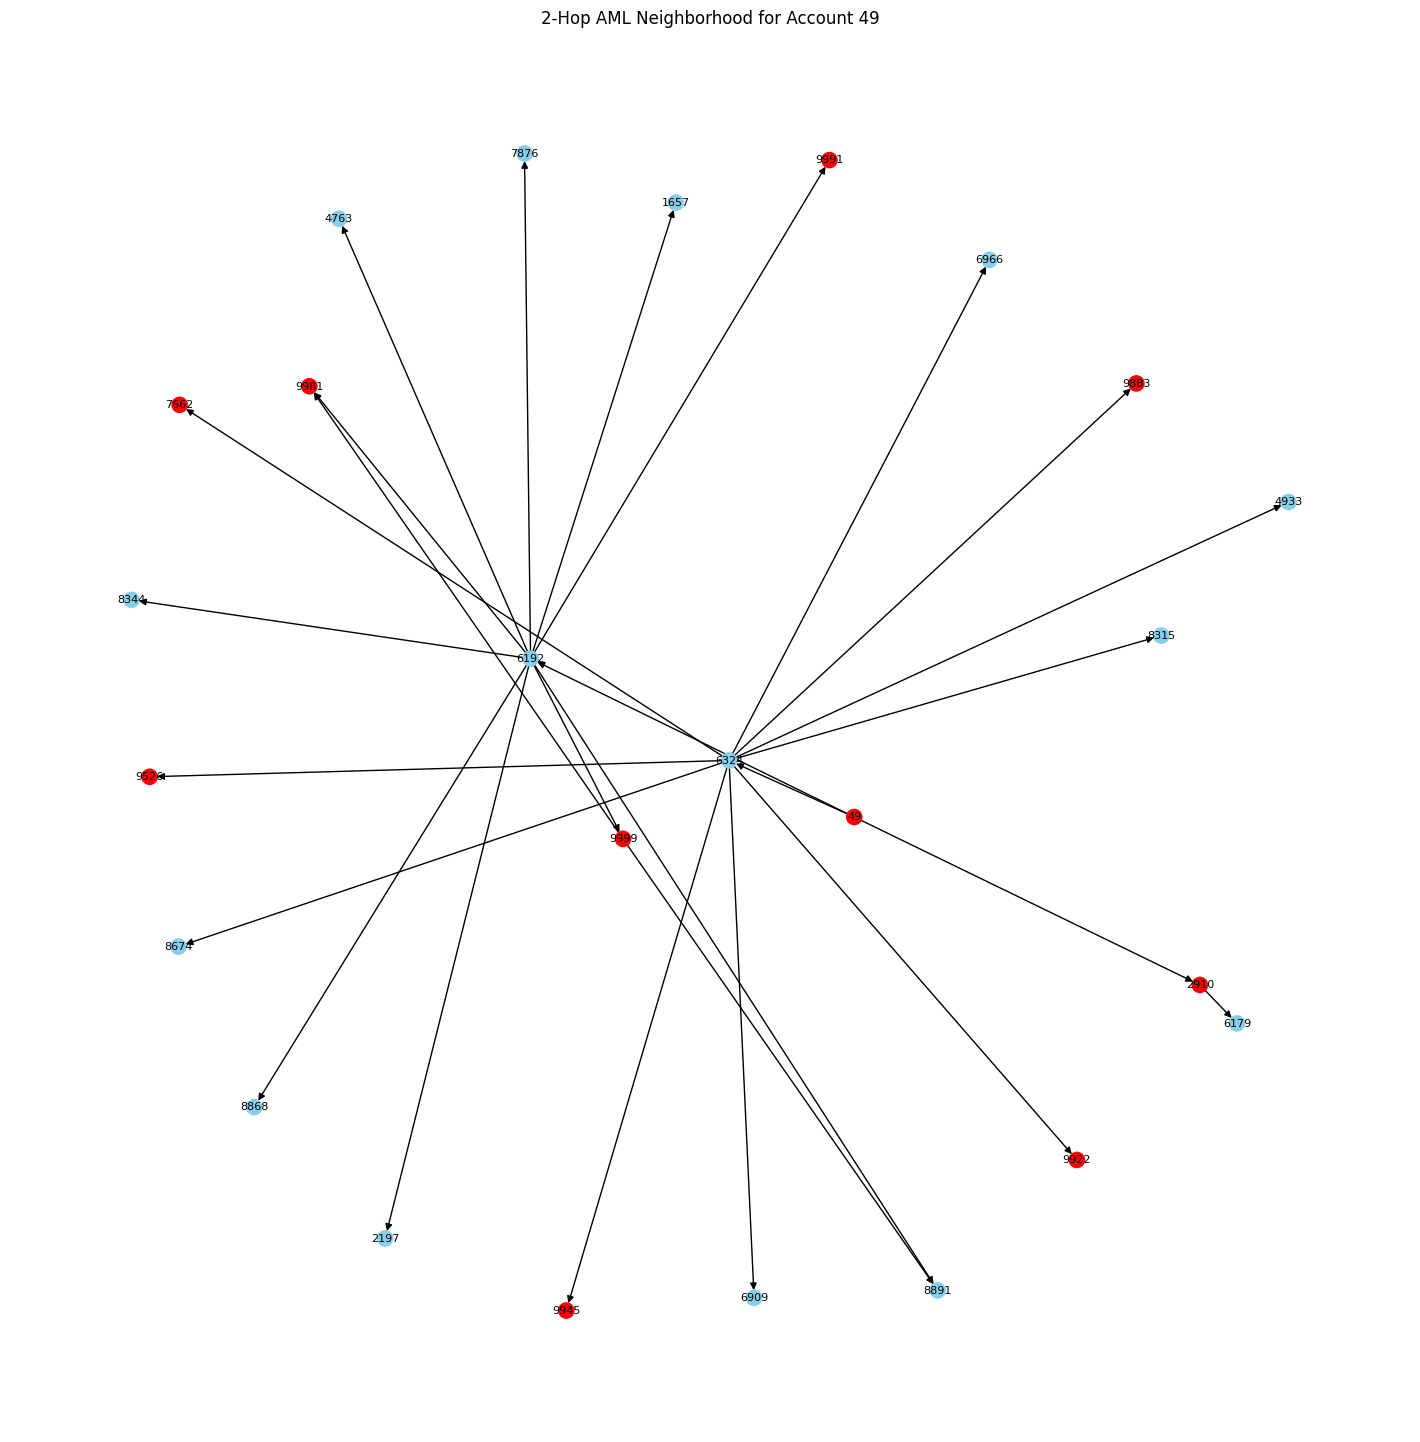

In [23]:
# STEP 5 — VISUALIZE INVESTIGATION NETWORK
plt.figure(figsize=(14,14))

pos = nx.spring_layout(
    local_subgraph,
    seed=42
)

nx.draw(
    local_subgraph,
    pos,
    node_color=node_colors,
    node_size=120,
    arrows=True,
    with_labels=True,
    font_size=8
)

plt.title(
    f"2-Hop AML Neighborhood for Account {target_account}"
)

plt.show()

In [ ]:
# suspicious local transaction topology.

# And this graph is MUCH more meaningful than random visualization.

# WHAT YOUR 2-HOP AML INVESTIGATION SHOWS
# 1. CENTRAL INTERMEDIARY ACCOUNTS

# You clearly have:

# highly connected center nodes.

# Visible examples:

# 6192
# 932

# These appear to operate as:

# transaction hubs.
# WHY IMPORTANT?

# This pattern suggests:

# fund aggregation,
# routing behavior,
# intermediary transfer coordination.

# Potentially:

# mule accounts,
# laundering intermediaries.

In [ ]:
# 2. FRAUD ACCOUNTS CONNECT THROUGH HUBS

# You can visibly see:

# red suspicious nodes

# connected via:

# blue intermediary nodes.

# This is VERY important.

# Because laundering networks often:

# hide behind intermediary accounts.

# Example visible structure:

# fraud → intermediary → fraud

# This is:

# relational laundering behavior.
# 3. FAN-IN + FAN-OUT TOPOLOGY

# You are simultaneously seeing:

# Fan-In

# Many accounts:

# → 6192
# Fan-Out

# Hub distributes:

# 932 →

# This is VERY consistent with:

# layering + fund routing.

In [ ]:
# next is 

# 1. Graph Metrics Engineering
# 2. Suspicious Motif Detection
# 3. GNN Dataset Preparation
# 4. Train First GNN

In [ ]:
# PHASE 1 — GRAPH METRICS ENGINEERING

# This phase creates:

# node intelligence features.

# These features become:

# GNN input features later.
# WHY IMPORTANT?

# Raw graph alone is weak.

# We want:

# behavioral graph signals.

# Examples:

# hubs,
# routing behavior,
# suspicious neighborhood density,
# influence,
# intermediary importance.

In [24]:
# STEP 1 — DEGREE CENTRALITY

# You already started this.

# Now formalize it.

degree_centrality = nx.degree_centrality(G)

In [25]:
# STEP 2 — BETWEENNESS CENTRALITY

# VERY important for AML.

# Measures:

# how often an account sits between other accounts.

# This detects:

# intermediaries,
# routing nodes,
# laundering bridges.

betweenness_centrality = nx.betweenness_centrality(
    G,
    k=500
)

In [26]:
# STEP 3 — PAGERANK

# Very useful.

# Measures:

# influence within graph.

pagerank_scores = nx.pagerank(G)
# WHY IMPORTANT?

# Accounts connected to:

# important suspicious accounts

# also become important.

In [27]:
# STEP 4 — CLUSTERING COEFFICIENT

# Measures:

# how tightly connected neighborhoods are.
clustering_scores = nx.clustering(
    G.to_undirected()
)
# WHY IMPORTANT?

# Fraud rings often:

# cluster together.

# Dense neighborhoods can indicate:

# collusion,
# laundering groups,
# mule communities.

In [28]:
# STEP 5 — CREATE NODE FEATURE TABLE

# THIS is CRITICAL.

# We now create:

# structured graph intelligence features.

node_features_df = pd.DataFrame({

    "ACCOUNT_ID": list(G.nodes()),

    "degree_centrality": [
        degree_centrality[n]
        for n in G.nodes()
    ],

    "betweenness_centrality": [
        betweenness_centrality[n]
        for n in G.nodes()
    ],

    "pagerank": [
        pagerank_scores[n]
        for n in G.nodes()
    ],

    "clustering_coefficient": [
        clustering_scores[n]
        for n in G.nodes()
    ]
})

In [53]:
# STEP 6 — ADD FRAUD LABELS

# This becomes:

# supervised learning target.


fraud_labels = accounts_df[
    ["ACCOUNT_ID", "IS_FRAUD"]
]

node_features_df = node_features_df.merge(
    fraud_labels,
    on="ACCOUNT_ID",
    how="left"
)

In [54]:
# STEP 7 — INSPECT FEATURES
node_features_df.head()

,ACCOUNT_ID,degree_centrality,betweenness_centrality,pagerank,clustering_coefficient,IS_FRAUD
0,6456,0.000300,0.000014,0.000064,0.000000,False
1,9069,0.003901,0.001763,0.001078,0.005348,False
2,7516,0.000800,0.000003,0.000042,0.000000,False
3,9543,0.002000,0.000116,0.000365,0.000000,False
4,2445,0.000700,0.000083,0.000057,0.000000,False


In [ ]:
# PHASE 2 — SUSPICIOUS MOTIF DETECTION

# NOW we begin:

# AML topology mining.
# WHAT IS A MOTIF?

# A motif =

# recurring suspicious graph structure.

# Examples:

# cycles,
# fan-in,
# fan-out,
# laundering chains.

In [56]:
# FIRST MOTIF — HIGH FAN-IN

in_degrees = dict(G.in_degree())

top_fan_in = sorted(
    in_degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_fan_in

[(9999, 192),
 (9998, 164),
 (9993, 161),
 (9982, 143),
 (9997, 140),
 (9994, 136),
 (9996, 135),
 (9992, 114),
 (9995, 114),
 (9991, 111),
 (9986, 110),
 (9980, 110),
 (9990, 109),
 (9983, 108),
 (9989, 107),
 (9984, 105),
 (9981, 103),
 (9971, 99),
 (9988, 98),
 (9987, 96)]

In [ ]:
# SECOND MOTIF — HIGH FAN-OUT

out_degrees = dict(G.out_degree())

top_fan_out = sorted(
    out_degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:20]

top_fan_out


# INTERPRETATION

# Potential:

# layering,
# distribution accounts.

[(9797, 49),
 (9799, 48),
 (9784, 47),
 (9795, 46),
 (9796, 46),
 (9781, 46),
 (9792, 46),
 (9785, 46),
 (9794, 46),
 (9790, 46),
 (9793, 46),
 (9798, 46),
 (9773, 45),
 (9789, 45),
 (9788, 45),
 (9787, 45),
 (9783, 45),
 (9776, 45),
 (9791, 45),
 (9777, 44)]

In [ ]:
# THIRD MOTIF — CYCLE DETECTION

# VERY important.

cycles = list(nx.simple_cycles(G))

len(cycles)
# SMALLER CYCLES
small_cycles = [
    c for c in cycles
    if len(c) <= 5
]

small_cycles[:10]

# WHY IMPORTANT?

# Cycles are:

# strong AML indicators.

# Especially:

# repeated fund circulation,
# layering loops.

In [ ]:
# STEP 2 — CREATE EDGE INDEX
# CELL
# edges = []

# for source, target in G.edges():

#     edges.append([
#         node_mapping[source],
#         node_mapping[target]
#     ])
# STEP 3 — CONVERT TO TENSOR
# CELL
# import torch

# edge_index = torch.tensor(
#     edges,
#     dtype=torch.long
# ).t().contiguous()
# STEP 4 — NODE FEATURES
# CELL
# feature_columns = [

#     "degree_centrality",
#     "betweenness_centrality",
#     "pagerank",
#     "clustering_coefficient"
# ]

# x = torch.tensor(

#     node_features_df[
#         feature_columns
#     ].values,

#     dtype=torch.float
# )
# STEP 5 — LABELS
# CELL
# y = torch.tensor(

#     node_features_df[
#         "IS_FRAUD"
#     ].astype(int).values,

#     dtype=torch.long
# )
# STEP 6 — CREATE GRAPH DATA OBJECT
# CELL
# from torch_geometric.data import Data

# data = Data(
#     x=x,
#     edge_index=edge_index,
#     y=y
# )
# HUGE MILESTONE

# You now officially have:

# GNN-ready AML graph data.

In [ ]:
## we will use the engineering features to build rule based fraud/AML detector 
# later we can train GNN when we have more data



In [ ]:
## rule based setup

# RULE 1 — ABNORMAL HUB
if degree_centrality > threshold:
    suspicious
# Interpretation:
# unusually connected account,
# possible aggregator.

# RULE 2 — INTERMEDIARY ROUTING ACCOUNT
if betweenness_centrality > threshold:
    suspicious
# Interpretation:
# laundering bridge,
# routing node.

# RULE 3 — DENSE FRAUD NEIGHBORHOOD
if clustering_coefficient > threshold:
    suspicious
# Interpretation:
# fraud ring,
# collusive cluster.
# RULE 4 — HIGH GRAPH INFLUENCE
if pagerank > threshold:
    suspicious

# Interpretation:

# suspicious influence,
# connected to risky nodes.

SyntaxError: invalid character '—' (U+2014) (996383843.py, line 17)

In [ ]:
# EXAMPLE
node_features_df["aml_risk_score"] = (

    node_features_df["degree_centrality"] * 0.3 +

    node_features_df["betweenness_centrality"] * 0.4 +

    node_features_df["pagerank"] * 0.2 +

    node_features_df["clustering_coefficient"] * 0.1
)
# THEN CLASSIFY
node_features_df["aml_alert"] = (
    node_features_df["aml_risk_score"] > 0.02
)
# THIS IS ACTUALLY EXTREMELY GOOD
# Because:
# the logic becomes explainable.
# Your future agent can say:
# Account 6192 was flagged because:
# - unusually high transaction connectivity,
# - high intermediary routing behavior,
# - dense suspicious neighborhood,
# - elevated graph influence score.

# This is:

# explainable graph intelligence.

In [31]:
# Deterministic measurable AML intelligence engine.
node_features_df.head()

,ACCOUNT_ID,degree_centrality,betweenness_centrality,pagerank,clustering_coefficient
0,6456,0.000300,0.000002,0.000064,0.000000
1,9069,0.003901,0.003103,0.001078,0.005348
2,7516,0.000800,0.000003,0.000042,0.000000
3,9543,0.002000,0.000113,0.000365,0.000000
4,2445,0.000700,0.000041,0.000057,0.000000


In [ ]:
# STEP 1 — MERGE FRAUD LABELS
fraud_labels = accounts_df[
    ["ACCOUNT_ID", "IS_FRAUD"]
]

In [33]:
# STEP 2 — JOIN LABELS
node_features_df = node_features_df.merge(
    fraud_labels,
    on="ACCOUNT_ID",
    how="left"
)

In [34]:
# STEP 3 — VERIFY


node_features_df.head()

,ACCOUNT_ID,degree_centrality,betweenness_centrality,pagerank,clustering_coefficient,IS_FRAUD
0,6456,0.000300,0.000002,0.000064,0.000000,False
1,9069,0.003901,0.003103,0.001078,0.005348,False
2,7516,0.000800,0.000003,0.000042,0.000000,False
3,9543,0.002000,0.000113,0.000365,0.000000,False
4,2445,0.000700,0.000041,0.000057,0.000000,False


In [ ]:
# AML RISK SCORE
## first tested rules that we may modify later to ensure higher F1 score

node_features_df["aml_risk_score"] = (

    node_features_df["degree_centrality"] * 0.3 +

    node_features_df["betweenness_centrality"] * 0.4 +

    node_features_df["pagerank"] * 0.2 +

    node_features_df["clustering_coefficient"] * 0.1
)

In [36]:
# ALERT CLASSIFICATION
node_features_df["aml_alert"] = (
    node_features_df["aml_risk_score"] > 0.02
)

In [37]:
# EVALUATION
from sklearn.metrics import (

    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [38]:
# TRUE VS PREDICTED
y_true = node_features_df["IS_FRAUD"].astype(int)

y_pred = node_features_df["aml_alert"].astype(int)


In [40]:
# METRICS
precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f1)

0.032615026208503206


In [41]:
# PRINT RESULTS
print(f"Precision: {precision:.4f}")

print(f"Recall: {recall:.4f}")

print(f"F1 Score: {f1:.4f}")

Precision: 0.8750
Recall: 0.0166
F1 Score: 0.0326


In [45]:
# hyperparameter tuning for graph intelligence rules.
search_space = [

    {
        "degree": 0.25,
        "betweenness": 0.25,
        "pagerank": 0.25,
        "clustering": 0.25
    },

    {
        "degree": 0.4,
        "betweenness": 0.3,
        "pagerank": 0.2,
        "clustering": 0.1
    },

    {
        "degree": 0.2,
        "betweenness": 0.5,
        "pagerank": 0.2,
        "clustering": 0.1
    },

    {
        "degree": 0.1,
        "betweenness": 0.6,
        "pagerank": 0.2,
        "clustering": 0.1
    },

    {
        "degree": 0.3,
        "betweenness": 0.2,
        "pagerank": 0.4,
        "clustering": 0.1
    },

    {
        "degree": 0.2,
        "betweenness": 0.2,
        "pagerank": 0.2,
        "clustering": 0.4
    }
]

In [46]:
# RESULTS STORAGE
results = []
# FULL HYPERPARAMETER SEARCH

for weights in search_space:

    risk_score = (

        node_features_df["degree_centrality"] * weights["degree"] +

        node_features_df["betweenness_centrality"] * weights["betweenness"] +

        node_features_df["pagerank"] * weights["pagerank"] +

        node_features_df["clustering_coefficient"] * weights["clustering"]
    )

    for threshold in thresholds:

        predictions = (
            risk_score > threshold
        ).astype(int)

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        results.append({

            "degree_weight": weights["degree"],

            "betweenness_weight": weights["betweenness"],

            "pagerank_weight": weights["pagerank"],

            "clustering_weight": weights["clustering"],

            "threshold": threshold,

            "precision": precision,

            "recall": recall,

            "f1": f1
        })
# RESULTS DATAFRAME
results_df = pd.DataFrame(results)
# BEST CONFIGURATION
best_results = results_df.sort_values(
    by="f1",
    ascending=False
).head(10)

print(best_results)

     degree_weight  betweenness_weight  pagerank_weight  clustering_weight  \
44            0.40                0.30             0.20               0.10   
164           0.30                0.20             0.40               0.10   
163           0.30                0.20             0.40               0.10   
45            0.40                0.30             0.20               0.10   
5             0.25                0.25             0.25               0.25   
6             0.25                0.25             0.25               0.25   
83            0.20                0.50             0.20               0.10   
123           0.10                0.60             0.20               0.10   
84            0.20                0.50             0.20               0.10   
207           0.20                0.20             0.20               0.40   

     threshold  precision    recall        f1  
44      0.0021   0.524730  0.692582  0.597084  
164     0.0021   0.554173  0.634421  0.591588

In [ ]:
## next steps are to save the best paramters

import json

best_configuration = {

    "degree_weight": 0.40,

    "betweenness_weight": 0.30,

    "pagerank_weight": 0.20,

    "clustering_weight": 0.10,

    "threshold": 0.0021,

    "precision": 0.524730,

    "recall": 0.692582,

    "f1": 0.597084
}

In [49]:
with open(
    "../configs/aml_config.json",
    "w"
) as f:

    json.dump(
        best_configuration,
        f,
        indent=4
    )

In [50]:
with open(
    "../configs/aml_config.json",
    "r"
) as f:

    config = json.load(f)

config

{'degree_weight': 0.4,
 'betweenness_weight': 0.3,
 'pagerank_weight': 0.2,
 'clustering_weight': 0.1,
 'threshold': 0.0021,
 'precision': 0.52473,
 'recall': 0.692582,
 'f1': 0.597084}